# Phase D — Final frozen-candidate evaluation

This notebook reads the saved Phase D outputs. It does not train or tune a model.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
table_dir = project_root / 'reports' / 'tables'
figure_dir = project_root / 'reports' / 'figures' / 'final'

metrics = json.loads((table_dir / 'final_holdout_metrics.json').read_text())
classification = pd.read_csv(table_dir / 'final_holdout_classification.csv')
regression = pd.read_csv(table_dir / 'final_holdout_regression.csv')
economics = pd.read_csv(table_dir / 'final_holdout_economics.csv')
importance = pd.read_csv(table_dir / 'final_holdout_feature_importance.csv')
simulation = pd.read_csv(table_dir / 'final_holdout_lightgbm_simulation.csv')


## Frozen configuration


In [2]:
pd.Series(metrics['configuration'], name='value').to_frame()


,value
result_schema_version,0.8.0
run_type,frozen_candidate_holdout
ticker,AAPL
levels,10
horizon_events,50
max_rows,None
rows_loaded,400391
development_fraction,0.8
exploratory_holdout_fraction,0.2
requested_purge_events,100


## Classification comparison


In [3]:
classification[['model', 'accuracy', 'balanced_accuracy', 'macro_f1', 'down_recall', 'flat_recall', 'up_recall']]


,model,accuracy,balanced_accuracy,macro_f1,down_recall,flat_recall,up_recall
0,majority_classifier,0.495370,0.333333,0.220846,1.000000,0.000000,0.000000
1,balanced_logistic,0.438554,0.432007,0.391739,0.501539,0.427976,0.366506
2,lightgbm_classifier,0.552225,0.461882,0.455993,0.633841,0.231789,0.520017


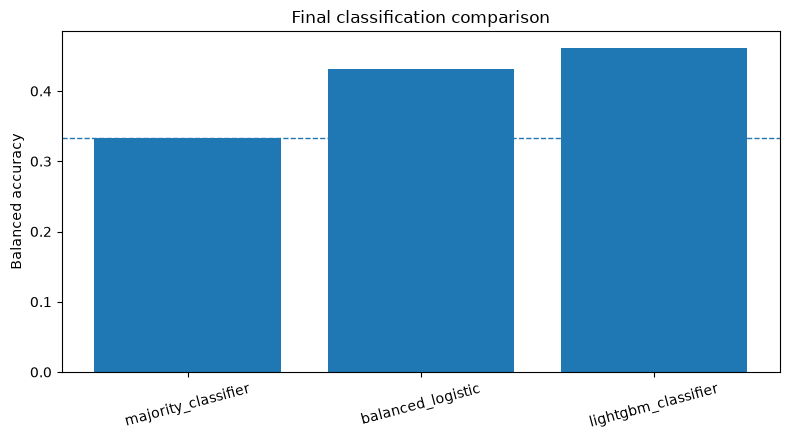

In [4]:
plt.figure(figsize=(8, 4.5))
plt.bar(classification['model'], classification['balanced_accuracy'])
plt.axhline(1/3, linestyle='--', linewidth=1)
plt.ylabel('Balanced accuracy')
plt.title('Final classification comparison')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## Return-prediction comparison


In [5]:
regression[['model', 'mae_bps', 'mae_improvement_pct_vs_zero', 'rank_ic', 'nonzero_directional_accuracy']]


,model,mae_bps,mae_improvement_pct_vs_zero,rank_ic,nonzero_directional_accuracy
0,zero_return,0.554541,0.000000,0.000000,0.000000
1,ridge,0.541482,2.354825,0.287596,0.630326
2,lightgbm_regressor,0.517579,6.665357,0.362545,0.652927


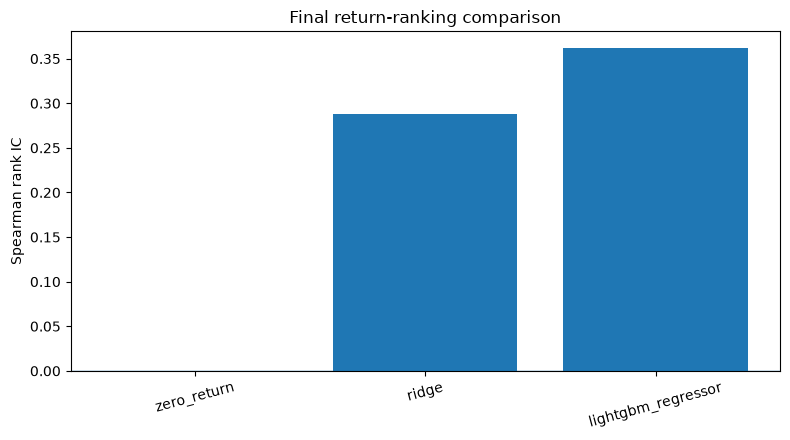

In [6]:
plt.figure(figsize=(8, 4.5))
plt.bar(regression['model'], regression['rank_ic'])
plt.axhline(0, linewidth=1)
plt.ylabel('Spearman rank IC')
plt.title('Final return-ranking comparison')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## Frozen-threshold economics


In [7]:
economics[['model', 'active_signal_fraction', 'mean_gross_return_active_bps', 'mean_estimated_cost_active_bps', 'mean_net_return_active_bps', 'break_even_cost_fraction', 'max_drawdown_bps']]


,model,active_signal_fraction,mean_gross_return_active_bps,mean_estimated_cost_active_bps,mean_net_return_active_bps,break_even_cost_fraction,max_drawdown_bps
0,balanced_logistic,0.542161,0.302951,1.775975,-1.472475,0.170780,-1276.635841
1,lightgbm_classifier,0.698314,0.289393,1.853972,-1.564166,0.156233,-1747.172966


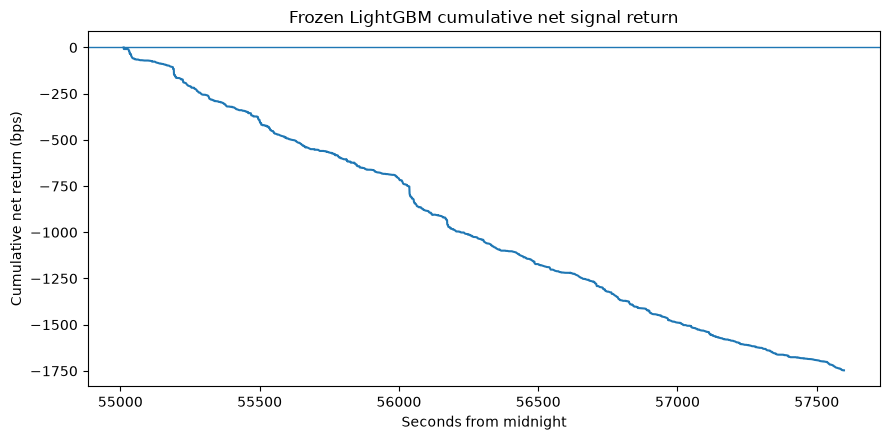

In [8]:
plt.figure(figsize=(9, 4.5))
plt.plot(simulation['time_seconds'], simulation['cumulative_net_bps'])
plt.axhline(0, linewidth=1)
plt.xlabel('Seconds from midnight')
plt.ylabel('Cumulative net return (bps)')
plt.title('Frozen LightGBM cumulative net signal return')
plt.tight_layout()
plt.show()


## Final feature importance


In [9]:
top = (importance[importance['model'] == 'lightgbm_classifier']
       .nlargest(15, 'normalized_gain_importance'))
top[['feature', 'normalized_gain_importance']]


,feature,normalized_gain_importance
0,spread_bps,0.100267
1,trade_pressure_20,0.094044
2,trade_pressure_50,0.087050
3,rolling_volatility_50,0.077811
4,rolling_volatility_20,0.070168
5,rolling_volatility_100,0.064043
6,event_intensity_20,0.049455
7,ofi_l1_sum_100,0.047777
8,queue_imbalance_l1,0.042114
9,event_intensity_100,0.033250


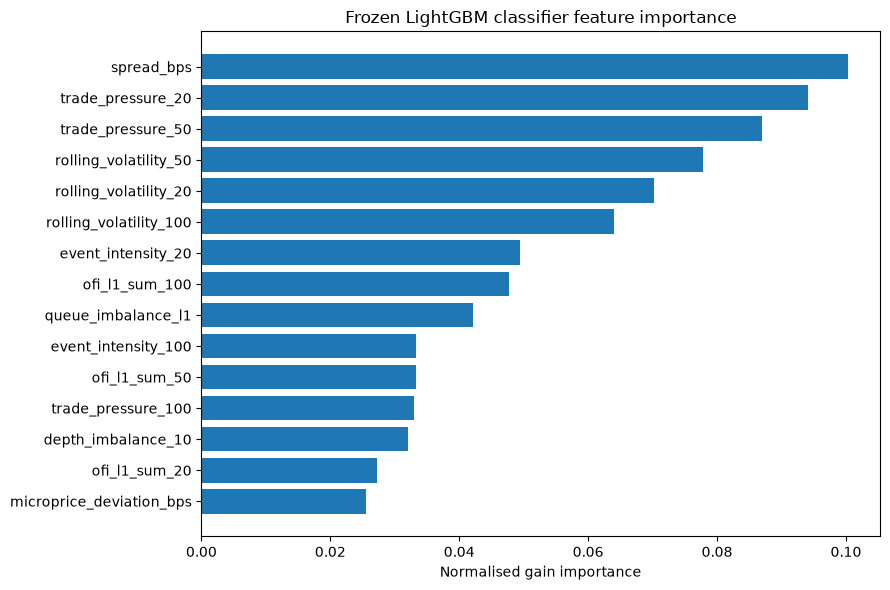

In [10]:
plt.figure(figsize=(9, 6))
plt.barh(top['feature'][::-1], top['normalized_gain_importance'][::-1])
plt.xlabel('Normalised gain importance')
plt.title('Frozen LightGBM classifier feature importance')
plt.tight_layout()
plt.show()


## Interpretation checklist

- Did LightGBM remain above the linear comparator on balanced accuracy and rank IC?
- Did it beat the zero-return MAE baseline?
- Is gross edge positive at the frozen threshold?
- Does gross edge cover the full estimated quoted-spread cost?
- Do not tune the model or threshold from this result.
